In [1]:
import numpy as np
import matplotlib.pyplot as plt

import hephaistos as hp
hp.selectDevice(0)
import hephaistos.pipeline as pl
from theia.volume import Attenuating
import theia
import theia.units as u

In [2]:
class MediumModel(
    theia.material.HenyeyGreensteinPhaseFunction,
    theia.material.DispersionFreeMedium,
):
    def __init__(self):
        super().__init__(
            n=1.15,
            ng=1.35,
            mu_a=0.04121681 / u.m,
            mu_s=0.0 / u.m,
            g=0.9,
            name="Eisschicht",
        )

medium = MediumModel().createMedium(physicModel = Attenuating())
store = theia.material.MaterialStore([], media=[medium])

rng = theia.random.PhiloxRNG(key=0xABBA)
response = theia.response.HistogramHitResponse(
    theia.response.UniformValueResponse(),
    binCount=200,
    binSize=2 * u.ns,
    t0 = 90 * u.ns
)
target = theia.target.SphereTarget(
    position= (31.25, -72.9300003051757, -383.3999938964844) * u.m,
    radius= 0.5 * u.m,
)
wavelength = theia.light.ConstWavelengthSource(405.0 * u.nm)
sharedStages = [target, wavelength, response, rng]

sphereLight = theia.light.SphericalLightSource(wavelength, mediumIdx=store.media["Eisschicht"])
batchSize = 16 * 1024 

from theia.ray import UnpolarizedRay

ray = UnpolarizedRay()
stats = theia.trace.EventStatisticCallback()
sphereTracer = theia.trace.VolumeForwardTracer(
    batchSize,
    ray,
    sphereLight,
    target,
    response,
    rng,
    store,
    volume="Eisschicht",
    callback = stats,
    maxPathLength=1000,
    disableTargetSampling=False,
)

spherePipeline = pl.Pipeline(sphereTracer.collectStages())

hists = []
def process(config: int, batch: int, args: None) -> None:
    hists.append(response.result(config).copy())

pipelineMap = {
    "sphere": spherePipeline,
}
scheduler = pl.PipelineScheduler(pipelineMap, processFn=process)


tasks = [
    ("sphere", {
        "lightSource__budget": 1e10,
        "lightSource__timeRange": (0.0, 0.10) * u.ns,
        "lightSource__position": (46.9072,-56.5889,-385.93) * u.m,
    }),
    ("sphere", {}),
    ("sphere", {}),
    ("sphere", {}),
    ("sphere", {}),
]
# submit work
scheduler.schedule(tasks)
scheduler.wait()

t = (
    np.arange(response.binCount) * response.binSize + response.t0
) / u.ns

# aggregate the five batches per light source
sphereSignal = np.mean(hists[:5], 0)
sphereSignalNorm = sphereSignal / (
    np.sum(sphereSignal) * response.binSize / u.ns
)
print(stats)

 absorbed: 10
  created: 81,920
  decayed: 0
 detected: 0
    error: 0
      hit: 0
     lost: 81,900
  maxIter: 10
 mismatch: 0
   missed: 0
scattered: 11,610,515
   volume: 0


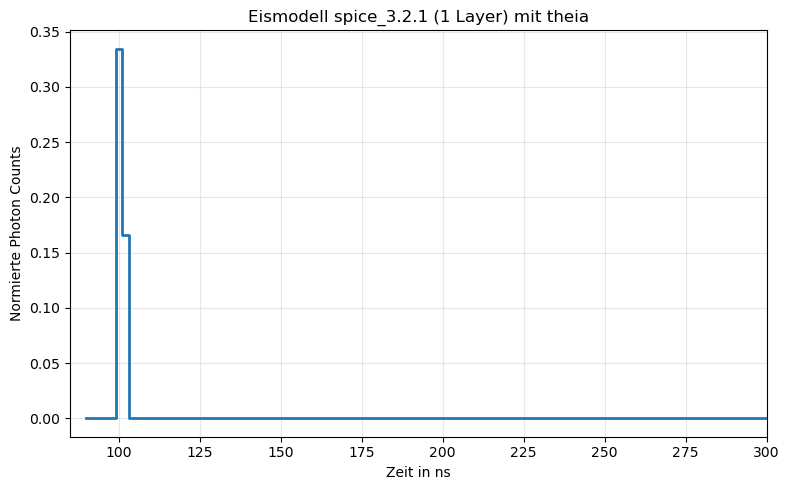

In [4]:
plt.figure(figsize=(8,5))
plt.step(
    t,
    sphereSignalNorm,
    where="mid",
    linewidth=2,
    label="Spherical source"
)

plt.xlabel("Zeit in ns")
plt.ylabel("Normierte Photon Counts")
plt.title(r"Eismodell spice_3.2.1 (1 Layer) mit theia")
#plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlim(85,300)

plt.tight_layout()
plt.savefig("SphereLightSource.pdf")
